In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("Titanic.csv")

df.head()

,pclass,survived,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


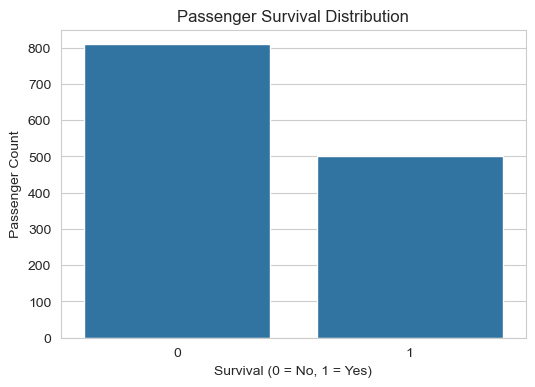

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='survived', data=df)
plt.title('Passenger Survival Distribution')
plt.xlabel('Survival (0 = No, 1 = Yes)')
plt.ylabel('Passenger Count')
plt.show()

The majority of passengers did not survive the Titanic disaster.
This supports the EDA finding that the overall survival rate was approximately 38%.

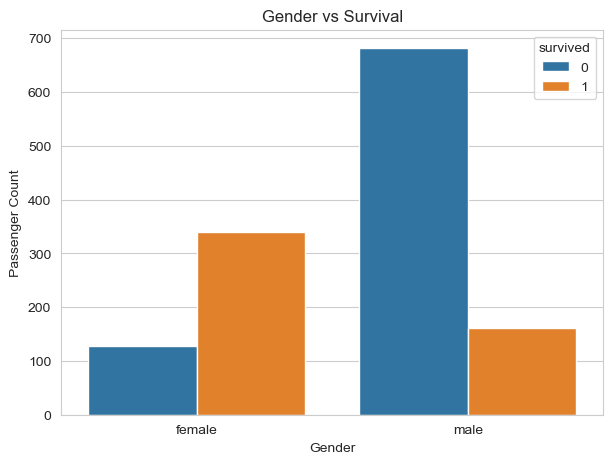

In [6]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='gender',
    hue='survived',
    data=df
)

plt.title('Gender vs Survival')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')

plt.show()

Female passengers had a substantially higher survival rate than male passengers.

Among females, 339 survived and 127 did not survive.

Among males, only 161 survived while 682 did not survive.

This indicates that gender was one of the strongest factors influencing survival.

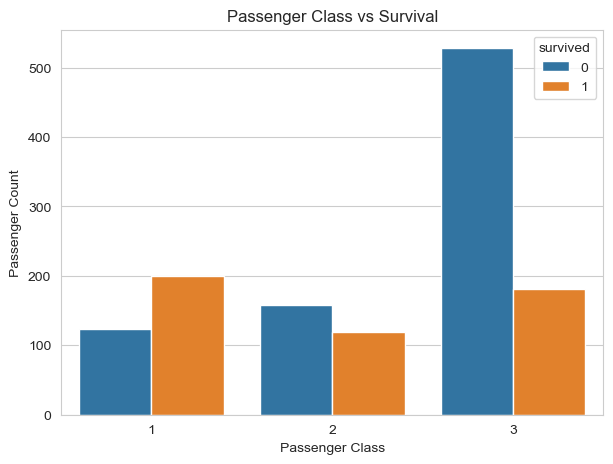

In [7]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='pclass',
    hue='survived',
    data=df
)

plt.title('Passenger Class vs Survival')
plt.xlabel('Passenger Class')
plt.ylabel('Passenger Count')

plt.show()

First-class passengers experienced significantly higher survival rates than third-class passengers.

Third-class passengers recorded the highest number of deaths.

Passenger class played a major role in determining survival chances.

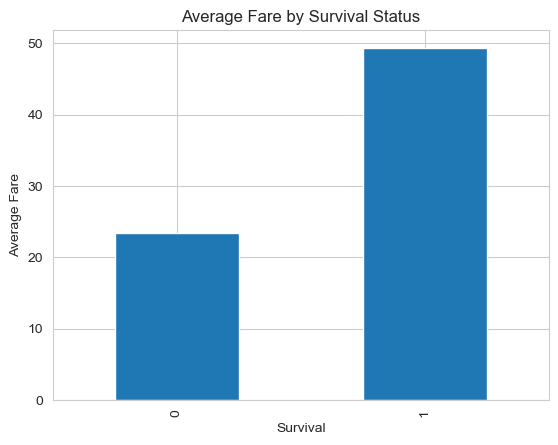

In [8]:
fare_survival = df.groupby('survived')['fare'].mean()

fare_survival.plot(
    kind='bar'
)

plt.title('Average Fare by Survival Status')
plt.xlabel('Survival')
plt.ylabel('Average Fare')

plt.show()

Passengers who survived paid considerably higher average fares than those who did not survive.

This supports the EDA finding that higher-paying passengers generally had better survival opportunities.

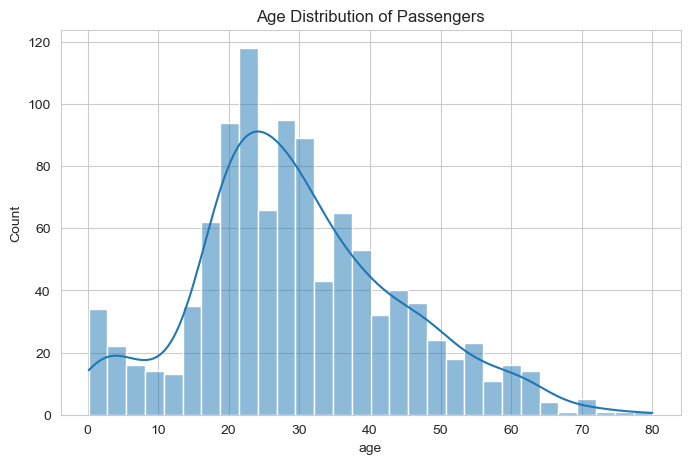

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    bins=30,
    kde=True
)

plt.title('Age Distribution of Passengers')

plt.show()

Most passengers were between 20 and 40 years old.

The distribution shows a concentration of young and middle-aged passengers with fewer elderly passengers.

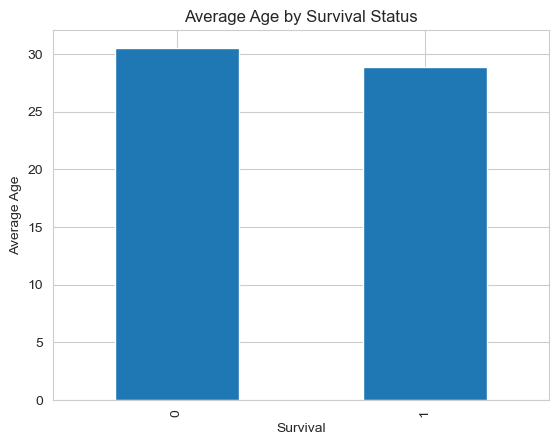

In [10]:
age_survival = df.groupby('survived')['age'].mean()

age_survival.plot(kind='bar')

plt.title('Average Age by Survival Status')
plt.xlabel('Survival')
plt.ylabel('Average Age')

plt.show()

The average ages of survivors and non-survivors are very similar.

This suggests that age had a weaker influence on survival compared to gender and passenger class.

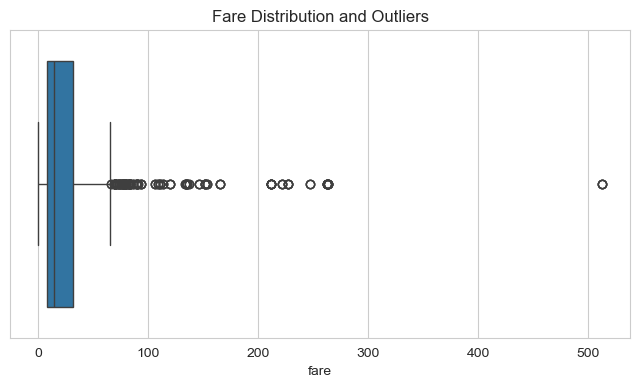

In [11]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['fare'])

plt.title('Fare Distribution and Outliers')

plt.show()

Several extreme fare values are visible as outliers.

These outliers correspond to passengers who paid exceptionally high fares and were likely traveling in premium accommodations.

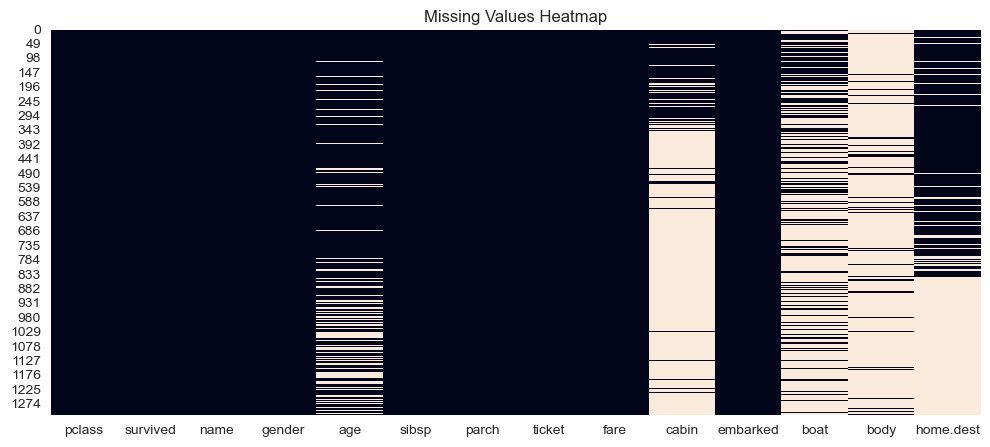

In [12]:
plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title('Missing Values Heatmap')

plt.show()

Several variables contain missing values.

Cabin, Body, Boat, and Home Destination have the highest concentration of missing data, which may affect future analyses.

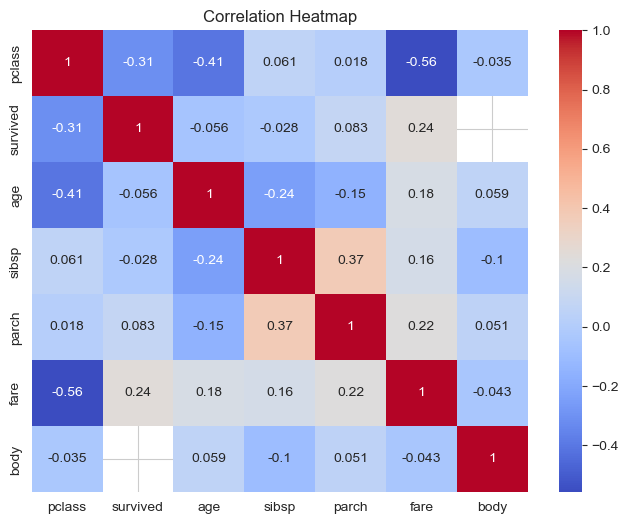

In [13]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

The heatmap highlights relationships among numerical variables.

Passenger class and fare show a notable relationship, while survival is associated with both passenger class and fare.

# Conclusion

The visual analysis confirms the findings from the exploratory data analysis.

Gender and passenger class were the most influential factors affecting survival.

Passengers who paid higher fares generally had better survival chances.

Age showed only a minor relationship with survival.

The dataset also contains significant missing values and fare outliers that should be considered during future modeling tasks.